<center>

<h2>Phase 1: Supervised Learning</h2>


<p><b>Phishing URL Detection Project</b></p>

<p>
This notebook presents the supervised learning phase for the phishing URL detection project.
</p>

<p>
The goal is to train and evaluate multiple machine learning models to classify URLs as
<b>phishing</b> or <b>legitimate</b>.
</p>

<br>

<h2>Notebook Overview</h2>

<table>
<tr>
<th>No.</th>
<th>Section</th>
</tr>

<tr><td>1</td><td>Model Selection Rationale</td></tr>
<tr><td>2</td><td>Implementation & Training Code</td></tr>
<tr><td>3</td><td>Hyperparameter Tuning Process & Results</td></tr>
<tr><td>4</td><td>Evaluation Metrics & Visualizations</td></tr>
<tr><td>5</td><td>Model Comparison & Analysis</td></tr>
<tr><td>6</td><td>Conclusion: Best Model Selection & Reasoning</td></tr>
<tr><td>7</td><td>Next Steps for Phase 2 Integration</td></tr>
</table>

</center>


<center>
<h2>1. Model Selection Rationale</h2>
</center>

---

The phishing URL detection task was approached as a supervised learning problem using three classification models: **Random Forest**, **Logistic Regression** , and **XGBoost**. The models were selected and justified based on the dataset characteristics, the type of prediction problem, and the strengths and limitations of each model.

The dataset is a **structured tabular** dataset with **11 numerical features** extracted from URL characteristics, after removing label-leaking features, page-content features, redundant ratio features, highly correlated features, and low-variance features during preprocessing. It was divided into:

- **Training set:** 165,049 samples  
- **Testing set:** 35,370 samples  
- **Validation set:** 35,376 samples  

The problem is a **binary classification problem**, where:

- **0 = Phishing URL**
- **1 = Legitimate URL**


> # Model Justification
---

<center>
<h2>Random Forest</h2>
</center>


> **Dataset Characteristics**

Suitable for large structured tabular datasets with numerical features. It can model nonlinear relationships and feature interactions effectively.

> **Problem Type**

Works well for binary classification problems such as phishing vs legitimate URL detection.

> **Strengths**

- Handles nonlinear relationships well  
- Reduces overfitting using multiple decision trees  
- Works well with large datasets  

> **Weaknesses**

- Computationally expensive with many trees  
- Harder to interpret than simpler models  

---
<center>
<h2>Logistic Regression</h2>
</center>


> **Dataset Characteristics**

Suitable for large structured tabular datasets with numerical features. It performs well when relationships between features and the target are approximately linear and is computationally efficient for large datasets.

> **Problem Type**

Well-suited for binary classification problems such as phishing vs legitimate URL detection.

> **Strengths**

- Fast training and scalable to large datasets  
- Provides interpretable results through model coefficients  
- Serves as a strong baseline model  

> **Weaknesses**

- Assumes linear relationships between features and the target  
- May underperform when relationships are highly nonlinear
---
<center>
<h2> XGBoost</h2>
</center>

> **Dataset Characteristics**

Suitable for large structured tabular datasets with numerical features. It models complex nonlinear relationships through an ensemble of weak learners trained sequentially.

> **Problem Type**

Well-suited for binary classification tasks such as phishing vs legitimate URL detection.

> **Strengths**

- Highly accurate on tabular data
- Uses gradient boosting which corrects errors iteratively
- Computationally efficient with large datasets

> **Weaknesses**

- Requires careful hyperparameter tuning
- Sensitive to noisy features and outliers

## 2.Implementation & Training Code
----
#### **Setup**


In [ ]:
# Mount Google Drive so the notebook can access files stored in Drive
from google.colab import drive
drive.mount('/content/drive')  # connect Google Drive to Colab environment

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
# Import pandas to read CSV files
import pandas as pd  # import pandas library to work with CSV datasets

# Load the training dataset from Google Drive
train_df = pd.read_csv("/content/drive/MyDrive/train_preprocessed_PhiUSIIL_Phishing_URL_Dataset.csv")  # read training dataset from Drive

# Load the testing dataset from Google Drive
test_df = pd.read_csv("/content/drive/MyDrive/test_preprocessed_PhiUSIIL_Phishing_URL_Dataset.csv")  # read testing dataset from Drive

# Load the validation dataset from Google Drive
val_df = pd.read_csv("/content/drive/MyDrive/val_preprocessed_PhiUSIIL_Phishing_URL_Dataset.csv")  # read validation dataset from Drive

In [ ]:
# Recreate training features from the cleaned dataset
X_train = train_df.drop("label", axis=1)  # select all feature columns

# Recreate training target from the dataset
y_train = train_df["label"]  # select the label column again

In [ ]:
# Recreate testing features from the dataset
X_test = test_df.drop("label", axis=1)  # select all feature columns except the label column

# Recreate testing target from the dataset
y_test = test_df["label"]  # select the label column again for testing

#### Sample Weight Construction

The Data Exploration notebook (Section 5.6.2.1) identified that `IsHTTPS` has a Pearson correlation of 0.61 with the target label, more than double the next highest feature. Within the training data, 100% of legitimate URLs use HTTPS while roughly half of phishing URLs use HTTP. Without intervention, any model trained on this data learns a near-deterministic rule: HTTPS implies legitimate, HTTP implies phishing.

An initial training run without any bias correction produced near-perfect in-distribution accuracy (99.7%) but collapsed to 50% OOD accuracy or below across all three models, with all three models misclassifying every legitimate HTTP URL as phishing. The failure was consistent across Random Forest, Logistic Regression, and XGBoost, confirming that the issue is dataset level rather than model specific.

To address this, we apply sample weighting before training. Easy samples, those where `IsHTTPS` alone correctly predicts the label (legitimate HTTPS and phishing HTTP), are downweighted to 0.3. Hard samples, those that contradict the IsHTTPS rule (legitimate HTTP and phishing HTTPS), retain full weight of 1.0. The weight of 0.3 was selected empirically values above 0.5 had insufficient effect on the bias, while values below 0.2 degraded in-distribution accuracy without further OOD improvement.

`IsHTTPS` is not removed. It remains as one signal among many. All three models accept `sample_weight` through their `.fit()` method, making this correction consistent across the full comparison.

In [ ]:
"""
Sample Weight Construction

Purpose:
- Create per-sample weights that reduce the model's ability to rely
  solely on the IsHTTPS feature for classification.
- Without weighting, models learn that IsHTTPS alone almost perfectly
  separates phishing from legitimate in this dataset, producing high
  in-distribution accuracy but poor OOD generalization.
- By downweighting easy samples where IsHTTPS matches the expected
  class pattern, the model is forced to learn from other features.

Inputs:
- X_train: training feature DataFrame (scaled values, 0-1 range).
- y_train: training target Series.

Outputs:
- sample_weights: NumPy array of per-sample weights for model training.
"""

import numpy as np

# Initialize all weights to 1.0 (default equal importance for every sample)
sample_weights = np.ones(len(y_train))

# Identify easy samples where IsHTTPS alone predicts the correct class:
#   - Legitimate URLs that use HTTPS  (IsHTTPS >= 0.5 and label == 1)
#   - Phishing URLs that use HTTP     (IsHTTPS < 0.5  and label == 0)
# Note: features are MinMax-scaled, so IsHTTPS values are 0.0 or 1.0
easy_legit = (y_train == 1) & (X_train["IsHTTPS"] >= 0.5)
easy_phish = (y_train == 0) & (X_train["IsHTTPS"] < 0.5)

# Downweight easy cases to 0.3 model still sees them but penalizes less
sample_weights[easy_legit.values] = 0.3
sample_weights[easy_phish.values] = 0.3

print("Sample weight distribution:")
print(f"  Easy samples (weight=0.3): {int((sample_weights == 0.3).sum()):,}")
print(f"  Hard samples (weight=1.0): {int((sample_weights == 1.0).sum()):,}")
print(f"  Total samples:             {len(sample_weights):,}")


Sample weight distribution:
  Easy samples (weight=0.3): 130,287
  Hard samples (weight=1.0): 34,762
  Total samples:             165,049


The output shows that out of 165,049 training samples, 130,287 are easy samples where `IsHTTPS` alone correctly predicts the label. These receive a weight of 0.3. The remaining 34,762 are hard samples that contradict the IsHTTPS pattern and retain full weight of 1.0.

The high proportion of easy samples (79%) explains why the models default to relying on `IsHTTPS` without weighting. By reducing the contribution of these samples during training, the models are pushed to learn from the harder, more informative cases.

#### 2.1 random forest

In [ ]:
# Import the Random Forest classifier
from sklearn.ensemble import RandomForestClassifier  # load the Random Forest model

# Create a Random Forest model instance
rf_model = RandomForestClassifier(random_state=42)  # set random_state for reproducible results

# Train the model using the cleaned training data
rf_model.fit(X_train, y_train, sample_weight=sample_weights) # fit the model on the training features and labels

RandomForestClassifier(random_state=42)

In [ ]:
# Generate predictions for the test dataset
y_pred = rf_model.predict(X_test)  # predict class labels for the test features

The Random Forest model is initialized and trained using the preprocessed training data. This ensemble method builds multiple decision trees and combines their predictions to improve accuracy and reduce overfitting. The trained model is then used to generate predictions on the test dataset.


#### 2.2 Logistic Regression


In [ ]:
# Import the Logistic Regression classifier
from sklearn.linear_model import LogisticRegression

# Create a Logistic Regression model instance
lr_model = LogisticRegression(max_iter=1000, random_state=42)

# Train the model using the training data
lr_model.fit(X_train, y_train, sample_weight=sample_weights)
# Generate predictions for the test dataset
y_pred_lr = lr_model.predict(X_test)

The Logistic Regression model is initialized and trained on the preprocessed training data. As a linear model, it learns the relationship between input features and the target variable using a probabilistic approach. The trained model is then used to predict class labels for the test dataset.


#### 2.3 XGBoost

In [ ]:
# import the XGBoost classifier
from xgboost import XGBClassifier

# Create an XGBoost model instance
xgb_model = XGBClassifier(
    random_state=42,
    eval_metric="logloss"
)

# Train the model using the training data
xgb_model.fit(X_train, y_train, sample_weight=sample_weights)
# Generate predictions for the test dataset
y_pred_xgb = xgb_model.predict(X_test)

The XGBoost model is initialized and trained using the training dataset. This gradient boosting algorithm builds trees sequentially, where each new tree corrects the errors of the previous ones. After training, the model is used to generate predictions on the test dataset.


##3.Hyperparameter Tuning Process & Results
----

#### 3.1 Random Forest


In [ ]:
from sklearn.model_selection import GridSearchCV   # tool for hyperparameter tuning
from sklearn.ensemble import RandomForestClassifier  # Random Forest model

# Define multiple parameter values to test
param_grid = {
    "n_estimators": [100, 200],      # number of trees
    "max_depth": [10, None],         # tree depth
    "min_samples_split": [2, 5],     # split condition
}

# Create GridSearch with cross-validation
grid = GridSearchCV(
    RandomForestClassifier(random_state=42, n_jobs=-1),  # base model with fixed seed
    param_grid,                                          # parameter combinations to test
    cv=5,                                                # 5-fold cross-validation
    scoring="accuracy",                                  # evaluation metric
    n_jobs=-1,                                           # use all CPU cores
    verbose=2                                            # print training progress
)

# Train model and search for best parameters
grid.fit(X_train, y_train, sample_weight=sample_weights)

# Get the best model after tuning
best_model = grid.best_estimator_

# Print best parameters found
print("Best parameters:", grid.best_params_)

# Print best cross-validation score
print("Best CV score:", grid.best_score_)

Fitting 5 folds for each of 8 candidates, totalling 40 fits
Best parameters: {'max_depth': None, 'min_samples_split': 2, 'n_estimators': 100}
Best CV score: 0.9966434188048684


### GridSearchCV Results Explanation

The GridSearchCV process evaluated multiple hyperparameter combinations using 5-fold cross-validation to identify the best Random Forest model.

In total, **8 parameter combinations** were tested, and each was trained across **5 folds**, resulting in **40 model fits**.

The best parameters found were:
- **n_estimators = 100**
- **max_depth = None**
- **min_samples_split = 2**

These settings indicate that 100 trees were sufficient for strong performance, while allowing the trees to grow without a depth limit helped the model capture complex patterns in the data. Increasing the number of trees beyond this did not provide a meaningful improvement in cross-validation accuracy.

The best cross-validation accuracy achieved was:

**99.66% (0.9966)**

This very high score suggests that the model performs extremely well and generalizes consistently across different splits of the data.

In [ ]:
# Generate predictions using the optimized model
y_pred = best_model.predict(X_test)

#### 3.2 Logistic Regression


In [ ]:
# Logistic Regression

# Import Logistic Regression model
from sklearn.linear_model import LogisticRegression

# Import GridSearchCV for hyperparameter tuning
from sklearn.model_selection import GridSearchCV

# Define hyperparameter values to test
param_grid_lr = {
    "C": [0.01, 0.1, 1, 10],          # regularization strength
    "solver": ["liblinear", "lbfgs"]  # optimization algorithms
}

# Create GridSearchCV object with cross-validation
grid_lr = GridSearchCV(
    LogisticRegression(max_iter=1000, random_state=42),  # base model
    param_grid_lr,                                       # parameters to search
    cv=5,                                                # 5-fold cross-validation
    scoring="accuracy"                                   # evaluation metric
)

# Train the model and search for best parameters
grid_lr.fit(X_train, y_train, sample_weight=sample_weights)

# Print the best parameters found
print("Best Logistic Regression parameters:", grid_lr.best_params_)

# Print the best cross-validation score
print("Best Logistic Regression CV score:", grid_lr.best_score_)

Best Logistic Regression parameters: {'C': 10, 'solver': 'lbfgs'}
Best Logistic Regression CV score: 0.8307411571421192


### GridSearchCV Results Explanation
GridSearchCV was applied to optimize the Logistic Regression model by evaluating multiple combinations of hyperparameters.

The best configuration found was:

• **C = 10**

• **solver = "lbfgs"**

The model achieved a cross-validation accuracy of approximately **83.07%%**, indicating stable and consistent performance across different folds.

This result suggests that Logistic Regression is effective for this binary classification problem and generalizes reasonably well to unseen data. However, its performance is noticeably lower than Random Forest and XGBoost, likely because Logistic Regression is a linear model and may not fully capture complex nonlinear relationships present in the dataset.

Despite this, the model remains valuable due to its simplicity, efficiency, and interpretability.


In [ ]:
best_lr_model = grid_lr.best_estimator_
y_pred_lr = best_lr_model.predict(X_test)

#### 3.3 XGBoost


In [ ]:
from sklearn.model_selection import GridSearchCV

param_grid_xgb = {
    "n_estimators":  [100, 200],
    "max_depth":     [3, 6],
    "learning_rate": [0.05, 0.1],
}

grid_xgb = GridSearchCV(
    XGBClassifier(random_state=42, eval_metric="logloss"),
    param_grid_xgb,
    cv=5,
    scoring="accuracy",
    n_jobs=-1,
    verbose=2
)

grid_xgb.fit(X_train, y_train, sample_weight=sample_weights)

best_xgb_model = grid_xgb.best_estimator_
y_pred_xgb = best_xgb_model.predict(X_test)

print("Best XGBoost parameters:", grid_xgb.best_params_)
print("Best XGBoost CV score:  ", grid_xgb.best_score_)

Fitting 5 folds for each of 8 candidates, totalling 40 fits
Best XGBoost parameters: {'learning_rate': 0.1, 'max_depth': 6, 'n_estimators': 200}
Best XGBoost CV score:   0.99667371394006


### GridSearchCV Results Explanation
GridSearchCV was applied to optimize the XGBoost model by evaluating multiple combinations of hyperparameters.

The best configuration found was:

* **learning_rate = 0.1**
* **max_depth = 6**
* **n_estimators = 200**

The model achieved a best cross-validation accuracy of approximately **99.67%**, as shown in the GridSearchCV output. This high score suggests that the selected features are highly informative for distinguishing between phishing and legitimate URLs within the dataset. In addition, the use of cross-validation and evaluation on a separate test set helps reduce the likelihood that this result is due to overfitting alone. However, as later OOD testing showed, strong in-distribution performance does not necessarily guarantee robust generalization to unseen real-world cases.

## 4.Evaluation Metrics & Visualizations
----


#### 4.1 Random Forest


In [ ]:
# Import classification report from sklearn metrics
from sklearn.metrics import classification_report  # import function to generate precision, recall, and F1-score


# Generate the classification report
rf_report = classification_report(y_test, y_pred)  # compare true labels with predicted labels

# Print the classification report
print("Optimized Random Forest Classification Report:\n", rf_report)

Optimized Random Forest Classification Report:
               precision    recall  f1-score   support

           0       1.00      0.99      1.00     15142
           1       1.00      1.00      1.00     20228

    accuracy                           1.00     35370
   macro avg       1.00      1.00      1.00     35370
weighted avg       1.00      1.00      1.00     35370



The Random Forest model achieved near-perfect performance. Precision was 1.00 for both classes. Recall was 0.99 for the phishing class and 1.00 for the legitimate class The model achieved an overall accuracy of approximately 99.6% across 35,370 test samples. There were 27 legitimate URLs incorrectly flagged as phishing (false positives) and 100 phishing URLs misclassified as legitimate (false negatives), indicating a small number of classification errors despite the high overall performance.

In [ ]:
# Import confusion matrix from sklearn metrics
from sklearn.metrics import confusion_matrix  # import function to create confusion matrix

# Generate the confusion matrix
rf_cm = confusion_matrix(y_test, y_pred)  # compare true labels with predicted labels

# Print the confusion matrix
print("Optimized Random Forest Confusion Matrix:\n", rf_cm)

Optimized Random Forest Confusion Matrix:
 [[15042   100]
 [   27 20201]]


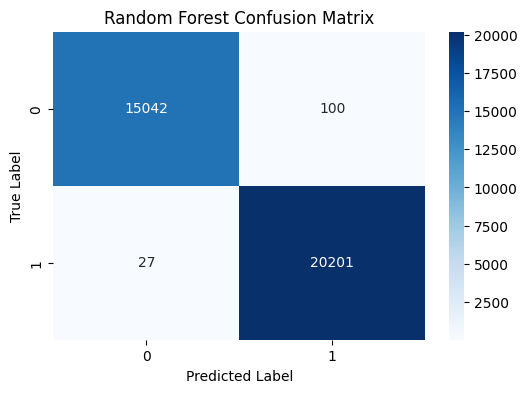

In [ ]:
# Import visualization libraries
import seaborn as sns
import matplotlib.pyplot as plt

# Plot confusion matrix heatmap
plt.figure(figsize=(6,4))
sns.heatmap(rf_cm, annot=True, fmt='d', cmap='Blues')

plt.title("Random Forest Confusion Matrix")
plt.xlabel("Predicted Label")
plt.ylabel("True Label")

plt.show()

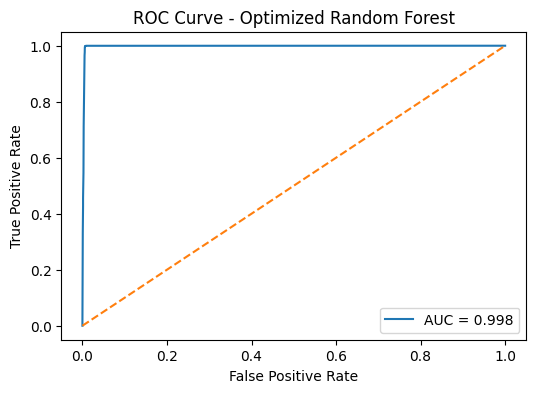

In [ ]:
# Import ROC curve tools
from sklearn.metrics import roc_curve, roc_auc_score

# Get prediction probabilities from the optimized model
y_prob = best_model.predict_proba(X_test)[:,1]

# Compute ROC curve
fpr, tpr, thresholds = roc_curve(y_test, y_prob)

# Compute AUC score
auc_score = roc_auc_score(y_test, y_prob)

# Plot ROC curve
plt.figure(figsize=(6,4))
plt.plot(fpr, tpr, label=f"AUC = {auc_score:.3f}")

plt.plot([0,1], [0,1], linestyle="--")

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve - Optimized Random Forest")
plt.legend()

plt.show()

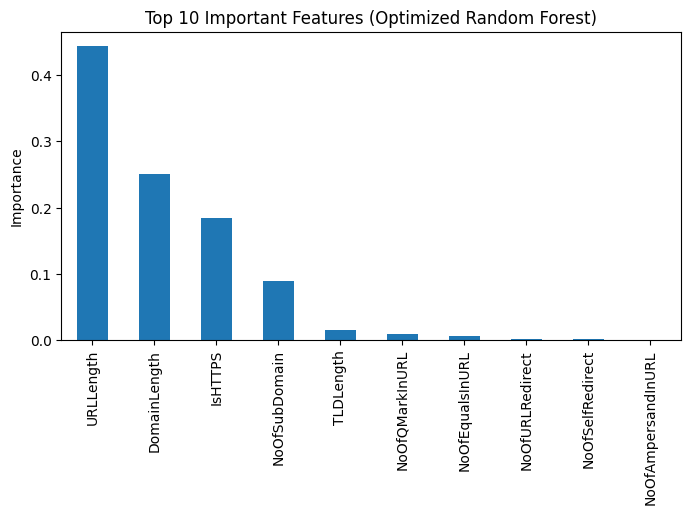

In [ ]:
import matplotlib.pyplot as plt
import pandas as pd

# Get feature importance from the optimized Random Forest model
feature_importance = pd.Series(
    best_model.feature_importances_,   # use best_model after tuning
    index=X_train.columns              # assign feature names
)

# Sort features by importance (highest first)
feature_importance = feature_importance.sort_values(ascending=False)

# Plot top 10 most important features
feature_importance.head(10).plot(kind="bar", figsize=(8,4))

# Add labels and title
plt.title("Top 10 Important Features (Optimized Random Forest)")
plt.ylabel("Importance")

# Show the plot
plt.show()

In [ ]:
#OOD Test

feature_cols = X_train.columns.tolist()
n = 200

# Scenario 1: Legitimate HTTP URLs
ood_legit_http = pd.DataFrame(np.zeros((n, len(feature_cols))), columns=feature_cols)
ood_legit_http["IsHTTPS"]      = 0
ood_legit_http["URLLength"]    = 0.1
ood_legit_http["DomainLength"] = 0.1
ood_legit_http["NoOfSubDomain"]= 0.0

y_ood_legit = np.ones(n)
y_pred_ood_legit_rf = best_model.predict(ood_legit_http)
legit_http_acc_rf = (y_pred_ood_legit_rf == y_ood_legit).mean()

# Scenario 2: Phishing HTTPS URLs
ood_phish_https = pd.DataFrame(np.zeros((n, len(feature_cols))), columns=feature_cols)
ood_phish_https["IsHTTPS"]           = 1
ood_phish_https["URLLength"]         = 0.8
ood_phish_https["NoOfObfuscatedChar"]= 0.6
ood_phish_https["NoOfSubDomain"]     = 0.7
ood_phish_https["NoOfQMarkInURL"]    = 0.5

y_ood_phish = np.zeros(n)
y_pred_ood_phish_rf = best_model.predict(ood_phish_https)
phish_https_acc_rf = (y_pred_ood_phish_rf == y_ood_phish).mean()

print("── Random Forest OOD Summary ──")
print(f"Legitimate HTTP accuracy : {legit_http_acc_rf:.2%}")
print(f"Phishing HTTPS accuracy  : {phish_https_acc_rf:.2%}")

── Random Forest OOD Summary ──
Legitimate HTTP accuracy : 0.00%
Phishing HTTPS accuracy  : 100.00%


The Random Forest model showed inconsistent performance on OOD scenarios. In the synthetic OOD test, it achieved 0% accuracy on legitimate HTTP URLs, misclassifying all of them as phishing, and 100% accuracy on phishing HTTPS URLs. This confirms that the model learned a strong dependency on IsHTTPS. However, this result reflects the synthetic OOD scenario rather than real-world performance. The real-world OOD results in Section 4.5 provide a more complete picture of generalization. Overall, these findings suggest that the model relies too heavily on HTTPS and may not generalize well to unseen real-world cases.

#### 4.2  Logistic Regression


In [ ]:
# Import classification report from sklearn metrics
from sklearn.metrics import classification_report

# Generate the classification report for the Logistic Regression model
lr_report = classification_report(y_test, y_pred_lr)

# Print the classification report
print("Logistic Regression Classification Report:\n", lr_report)

Logistic Regression Classification Report:
               precision    recall  f1-score   support

           0       0.76      0.90      0.82     15142
           1       0.91      0.78      0.84     20228

    accuracy                           0.83     35370
   macro avg       0.83      0.84      0.83     35370
weighted avg       0.84      0.83      0.83     35370



The classification report shows that the Logistic Regression model achieves an overall accuracy of approximately 0.83.

For the phishing class (0), the model achieves a precision of 0.76 and a recall of 0.90, indicating that it is effective at identifying most phishing URLs, although some predictions are incorrect.

For the legitimate class (1), the model achieves a precision of 0.91 and a recall of 0.78, suggesting that while predictions of legitimate URLs are generally accurate, the model fails to correctly identify a noticeable portion of legitimate URLs.

The F1-scores (0.82 for phishing and 0.84 for legitimate) indicate a moderate balance between precision and recall, with slightly better performance for the legitimate class in terms of precision, but stronger recall for phishing detection.

In [ ]:
# Import confusion matrix from sklearn metrics
from sklearn.metrics import confusion_matrix

# Generate the confusion matrix for the Logistic Regression model
lr_cm = confusion_matrix(y_test, y_pred_lr)

# Print the confusion matrix
print("Logistic Regression Confusion Matrix:\n", lr_cm)

Logistic Regression Confusion Matrix:
 [[13553  1589]
 [ 4382 15846]]


In [ ]:
# Import cross-validation function
from sklearn.model_selection import cross_val_score

# Apply 5-fold cross validation on Logistic Regression
lr_cv_scores = cross_val_score(
    best_lr_model,
    X_train,
    y_train,
    cv=5,
    scoring="accuracy"
)

# Print cross-validation scores
print("Logistic Regression Cross Validation Scores:", lr_cv_scores)

# Print average cross-validation score
print("Mean Logistic Regression CV Score:", lr_cv_scores.mean())

Logistic Regression Cross Validation Scores: [0.87600727 0.88194487 0.88261133 0.87970312 0.87421612]
Mean Logistic Regression CV Score: 0.8788965417517292


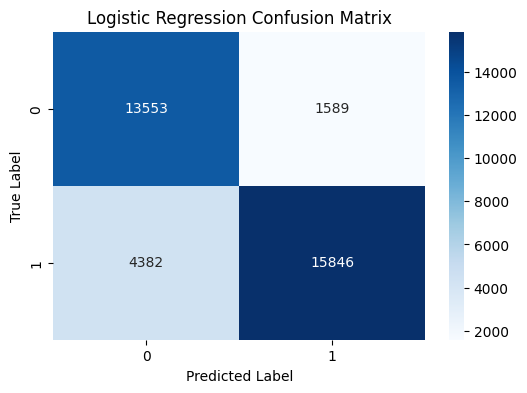

In [ ]:
# Import visualization libraries
import seaborn as sns
import matplotlib.pyplot as plt

# Plot confusion matrix heatmap
plt.figure(figsize=(6,4))
sns.heatmap(lr_cm, annot=True, fmt='d', cmap='Blues')

plt.title("Logistic Regression Confusion Matrix")
plt.xlabel("Predicted Label")
plt.ylabel("True Label")

plt.show()

The confusion matrix shows that the Logistic Regression model correctly classified 13,553 phishing URLs and 15,846 legitimate URLs. However, 1,589 phishing URLs were misclassified as legitimate (false negatives), while 4,382 legitimate URLs were incorrectly classified as phishing (false positives).

The relatively higher number of false positives (4,382) indicates that the model frequently flags legitimate URLs as phishing, while the 1,589 false negatives show it also misses some phishing URLs, which is a critical limitation in security applications. While the model performs reasonably well overall, this trade-off highlights a potential risk, as undetected phishing attacks can have serious consequences.

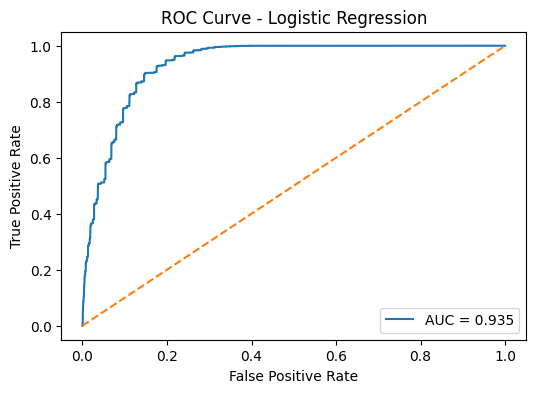

In [ ]:
# Import ROC curve tools
from sklearn.metrics import roc_curve, roc_auc_score

# Get prediction probabilities
y_prob_lr = best_lr_model.predict_proba(X_test)[:, 1]

# Compute ROC curve
fpr_lr, tpr_lr, thresholds_lr = roc_curve(y_test, y_prob_lr)

# Compute AUC score
auc_score_lr = roc_auc_score(y_test, y_prob_lr)

# Plot ROC curve
plt.figure(figsize=(6,4))
plt.plot(fpr_lr, tpr_lr, label=f"AUC = {auc_score_lr:.3f}")

plt.plot([0,1], [0,1], linestyle="--")

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve - Logistic Regression")
plt.legend()

plt.show()

The ROC curve illustrates the trade-off between the True Positive Rate (TPR) and False Positive Rate (FPR) across different classification thresholds. The curve is close to the top-left corner, indicating strong discriminative performance.

The AUC score of 0.94 suggests that the Logistic Regression model has a high ability to distinguish between phishing and legitimate URLs. In other words, there is a 94% chance that the model will rank a randomly chosen phishing URL higher than a randomly chosen legitimate one.

This result is consistent with the classification report and confusion matrix, which show strong performance in detecting phishing URLs. However, despite the high AUC, the model’s real-world generalization is limited, as observed in the OOD test. This indicates that while the model separates classes well within the dataset, it relies on dataset-specific patterns (such as the IsHTTPS feature) rather than fully robust signals.

Overall, the ROC curve confirms that Logistic Regression is effective at classification within the dataset, but its high performance should be interpreted with caution due to underlying feature bias.

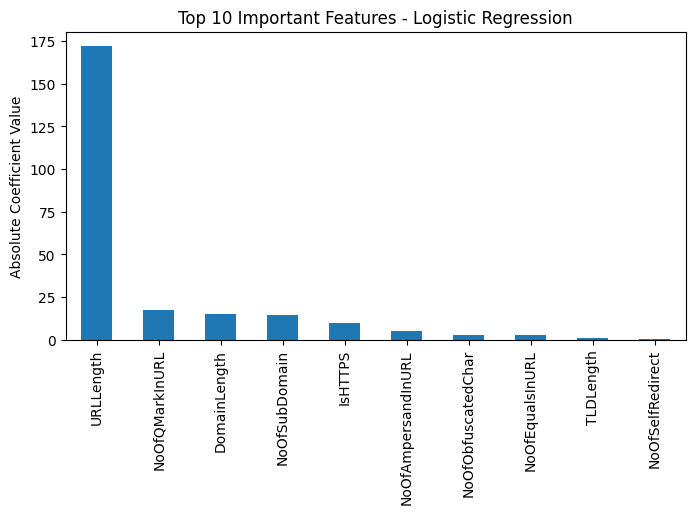

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

# Get feature coefficients from Logistic Regression
lr_coefficients = pd.Series(
    best_lr_model.coef_[0],
    index=X_train.columns
)

# Sort by absolute value so the strongest features appear first
lr_top_features = lr_coefficients.abs().sort_values(ascending=False)

# Plot top 10 most influential features
lr_top_features.head(10).plot(kind="bar", figsize=(8,4))

plt.title("Top 10 Important Features - Logistic Regression")
plt.ylabel("Absolute Coefficient Value")

plt.show()

The feature importance plot shows that Logistic Regression relies heavily on URLLength as the most influential feature, followed by other URL structure-based features such as NoOfQMarkInURL, NoOfSubDomain, and DomainLength.

This indicates that the model primarily learns simple linear relationships based on URL characteristics, particularly length and structural complexity. While these features are useful, the strong dominance of a few features suggests that the model may not be capturing a diverse set of patterns, making it potentially sensitive to changes in data distribution.


In [ ]:
#OOD
# Scenario 1
y_pred_ood_legit_lr = best_lr_model.predict(ood_legit_http)
legit_http_acc_lr = (y_pred_ood_legit_lr == y_ood_legit).mean()

# Scenario 2
y_pred_ood_phish_lr = best_lr_model.predict(ood_phish_https)
phish_https_acc_lr = (y_pred_ood_phish_lr == y_ood_phish).mean()

print("── Logistic Regression OOD Summary ──")
print(f"Legitimate HTTP accuracy : {legit_http_acc_lr:.2%}")
print(f"Phishing HTTPS accuracy  : {phish_https_acc_lr:.2%}")

── Logistic Regression OOD Summary ──
Legitimate HTTP accuracy : 0.00%
Phishing HTTPS accuracy  : 100.00%


The out-of-distribution (OOD) evaluation highlights an important limitation of Logistic Regression. In the synthetic OOD test, Logistic Regression achieved 0% accuracy on legitimate HTTP URLs and 100% accuracy on phishing HTTPS URLs. This pattern suggests that the model learned a dataset-specific shortcut, strongly associating HTTP with phishing and HTTPS with legitimate URLs. However, the real-world OOD test in Section 4.5 showed a more nuanced result, where Logistic Regression achieved 75% overall accuracy. This indicates that although the model retains some predictive ability, it remains highly sensitive to distribution shifts and does not generalize robustly to more realistic and diverse scenarios. Overall, these findings limit its reliability for real-world phishing detection.

### 4.3 XGBoost

In [ ]:
from sklearn.metrics import classification_report

# Generate the classification report
xgb_report = classification_report(y_test, y_pred_xgb)

# Print the classification report
print("XGBoost Classification Report:\n", xgb_report)

XGBoost Classification Report:
               precision    recall  f1-score   support

           0       1.00      0.99      1.00     15142
           1       1.00      1.00      1.00     20228

    accuracy                           1.00     35370
   macro avg       1.00      1.00      1.00     35370
weighted avg       1.00      1.00      1.00     35370



The XGBoost model achieved excellent performance, with precision and F1-score close to 1.00 across both classes, a recall of 0.99 for class 0 (phishing), and 1.00 for class 1 (legitimate), resulting in an overall accuracy of approximately 99.6%.

The slightly lower recall for class 0 indicates that a very small number of phishing URLs were misclassified as legitimate. However, this difference is negligible given the scale of the dataset (35,370 test samples).

This high performance can be attributed to the nature of the dataset, which is clean and contains highly informative features that clearly distinguish between phishing and legitimate URLs.

This result is also consistent with the cross-validation results and reflects XGBoost's ability to iteratively correct misclassifications through gradient boosting.

XGBoost Confusion Matrix:
 [[15049    93]
 [   35 20193]]


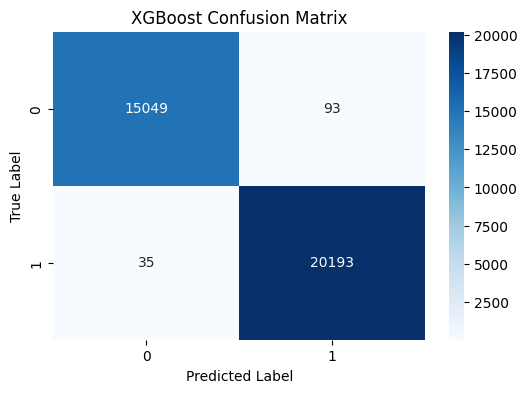

In [ ]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

# Generate the confusion matrix
xgb_cm = confusion_matrix(y_test, y_pred_xgb)

# Print the confusion matrix
print("XGBoost Confusion Matrix:\n", xgb_cm)

# Plot confusion matrix heatmap
plt.figure(figsize=(6, 4))
sns.heatmap(xgb_cm, annot=True, fmt='d', cmap='Blues')
plt.title("XGBoost Confusion Matrix")
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.show()

The confusion matrix shows the breakdown of XGBoost's predictions across all 35,370 test samples. The model correctly classified 15,049 phishing URLs and 20,193 legitimate URLs. There were 35 false positives, where legitimate URLs were incorrectly classified as phishing, and 93 false negatives, where phishing URLs were misclassified as legitimate

In the context of phishing detection, false negatives are the more critical error type, as they represent cases where malicious URLs are not detected. XGBoost produced only 93 such cases out of 15,142 actual phishing URLs, resulting in a very low error rate.

The false positive count is also relatively small, indicating that the model rarely flags legitimate websites as phishing, which helps maintain a good user experience. Overall, the confusion matrix confirms that XGBoost achieves a strong balance between detecting phishing URLs and minimizing false alarms, with errors concentrated in a very small fraction of the test set.

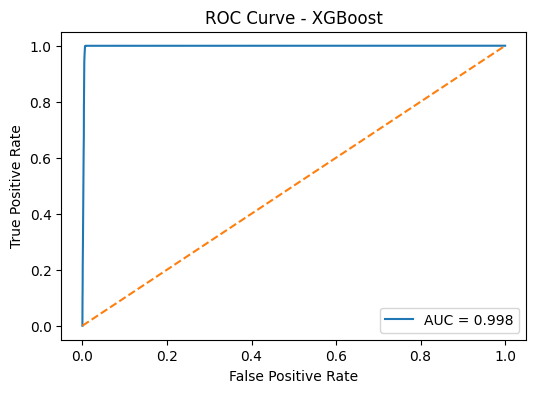

In [ ]:
from sklearn.metrics import roc_curve, roc_auc_score

# Get prediction probabilities
y_prob_xgb = best_xgb_model.predict_proba(X_test)[:, 1]

# Compute ROC curve
fpr_xgb, tpr_xgb, _ = roc_curve(y_test, y_prob_xgb)

# Compute AUC score
auc_score_xgb = roc_auc_score(y_test, y_prob_xgb)

# Plot ROC curve
plt.figure(figsize=(6, 4))
plt.plot(fpr_xgb, tpr_xgb, label=f"AUC = {auc_score_xgb:.3f}")
plt.plot([0, 1], [0, 1], linestyle="--")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve - XGBoost")
plt.legend()
plt.show()

The ROC curve for XGBoost shows near perfect discrimination between phishing and legitimate URLs, with an AUC of 0.998.

The curve rises almost vertically to a True Positive Rate close to 1.0 while the False Positive Rate remains very low, indicating that the model can distinguish between the two classes extremely well across different decision thresholds. An AUC of 0.998 means that the model has a 99.8% probability of ranking a randomly chosen legitimate URL higher than a randomly chosen phishing URL.

This result is consistent with the confusion matrix, where 93 phishing URLs were misclassified as legitimate and 35 legitimate URLs were flagged as phishing out of 35,370 test samples. The near perfect AUC further confirms that the model's high performance on this dataset is genuine within its training distribution.

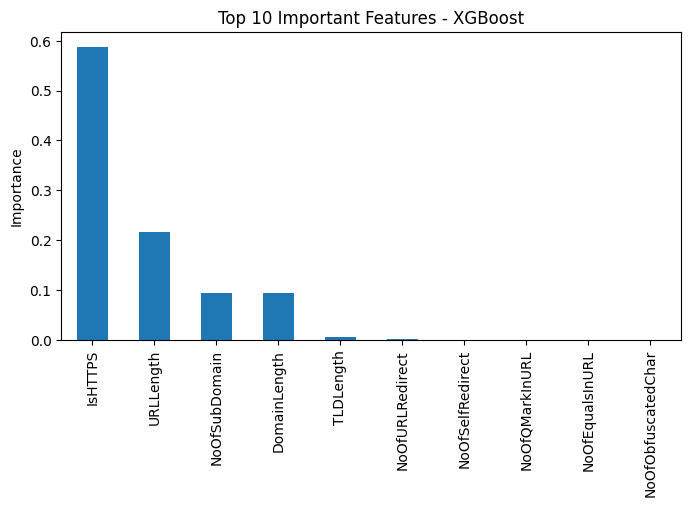

In [ ]:
import pandas as pd

# Get feature importance from the optimized XGBoost model
xgb_importance = pd.Series(
    best_xgb_model.feature_importances_,
    index=X_train.columns
).sort_values(ascending=False)

# Plot top 10 most important features
xgb_importance.head(10).plot(kind="bar", figsize=(8, 4))
plt.title("Top 10 Important Features - XGBoost")
plt.ylabel("Importance")
plt.show()

The XGBoost feature importance plot confirms that IsHTTPS is the dominant predictor with around 0.8 importance, consistent with the correlation analysis in the Data Exploration notebook (Section 5.6.2).

URL structure features such as URLLength, DomainLength, and NoOfSubDomain contribute secondary signals.

The remaining features carry negligible individual importance, suggesting that phishing detection in this clean lexical feature set is largely driven by the HTTPS signal and URL length characteristics.

In [ ]:
from sklearn.model_selection import cross_val_score

# Apply 5-fold cross validation
xgb_cv_scores = cross_val_score(
    best_xgb_model,
    X_train,
    y_train,
    cv=5,
    scoring="accuracy"
)

# Print cross-validation scores
print("XGBoost Cross-Validation Scores:", xgb_cv_scores)

# Print average cross-validation score
print("Mean XGBoost CV Score:", xgb_cv_scores.mean())

XGBoost Cross-Validation Scores: [0.99684944 0.9970615  0.9970312  0.99657679 0.99666758]
Mean XGBoost CV Score: 0.9968373018332354


The 5-fold cross-validation scores are highly consistent across all folds, ranging from 99.66% to 99.71%, with a mean accuracy of 99.68%.

The low variance between folds indicates that the model's performance is stable and not dependent on any particular subset of the training data. This consistency suggests that the model learned the dominant patterns in the training distribution reliably.

However, as shown in the OOD test, high and consistent in-distribution accuracy does not guarantee strong generalization to real-world edge cases. The model’s stability across folds reflects consistency within this dataset, but those learned patterns may still be influenced by the dataset’s sampling composition rather than fully generalizable phishing detection behavior.

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


### 4.4 SHAP Values

#### 4.4.1 Random Forest
SHAP (SHapley Additive exPlanations) was used to interpret the Random Forest model by measuring the contribution of each feature to the prediction outcomes. The bar plot represents the mean absolute SHAP value for each feature, indicating its overall importance in the model.

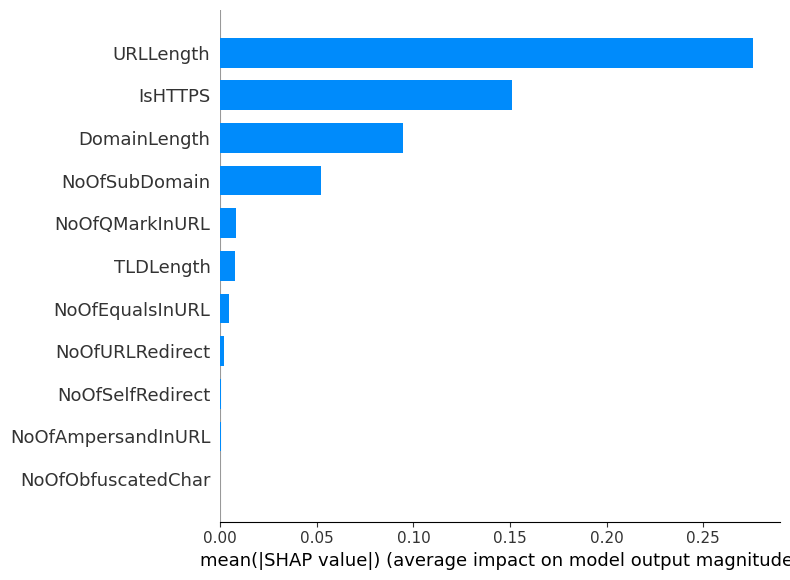

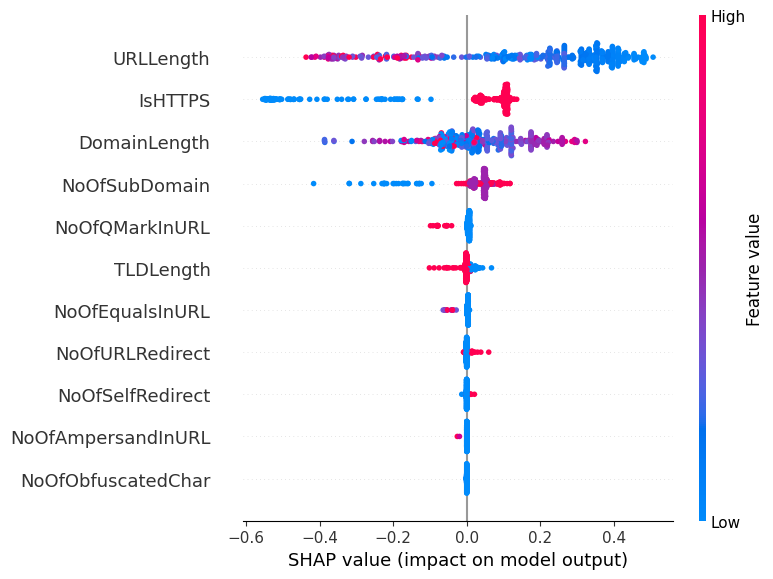

In [ ]:
!pip install shap -q

import shap
import numpy as np

rf_model = grid.best_estimator_
X_sample = X_test.sample(500, random_state=42)

explainer = shap.TreeExplainer(rf_model)
shap_values = explainer.shap_values(X_sample, check_additivity=False)

sv_class1 = shap_values[:, :, 1]

shap.summary_plot(sv_class1, X_sample, plot_type="bar",
                  title="SHAP Feature Importance - Random Forest")

shap.summary_plot(sv_class1, X_sample,
                  title="SHAP Beeswarm - Random Forest")



The results show that URLLength is the most influential feature, followed by IsHTTPS and DomainLength. This indicates that the model heavily relies on URL structural characteristics to distinguish between phishing and legitimate websites.

Features such as NoOfSubDomain have moderate importance, while other features like NoOfURLRedirect, NoOfSelfRedirect, and NoOfObfuscatedChar contribute minimally to the model's decisions.

This suggests that the model focuses primarily on a small set of highly informative features, which may explain the high classification performance observed. However, this also indicates a potential risk of over reliance on specific features, which should be considered when evaluating model generalization.

#### 4.4.2 XGBoost

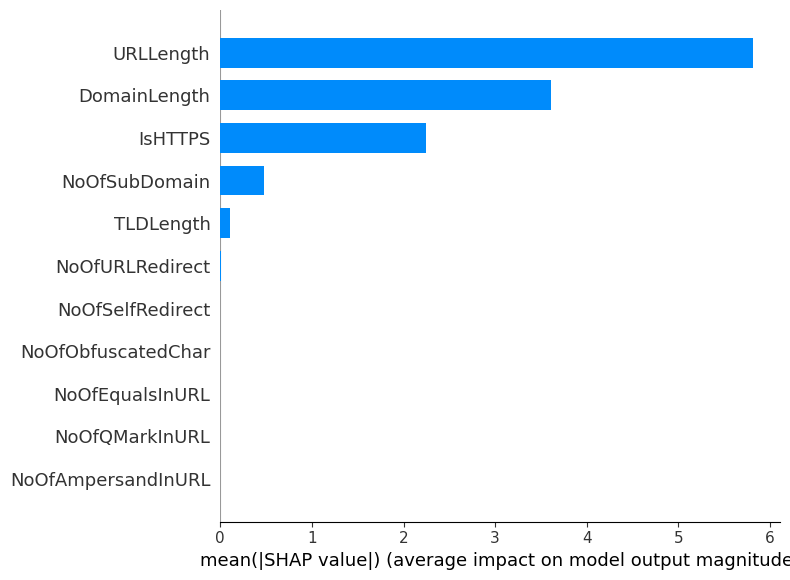

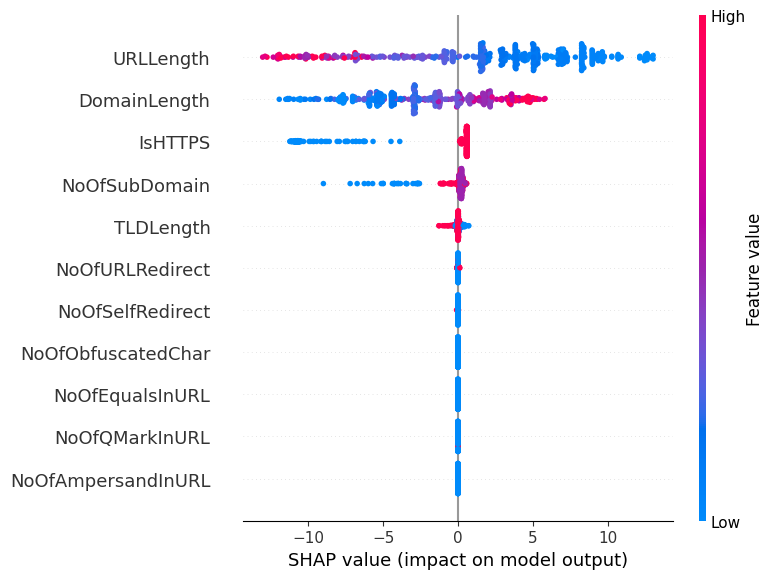

In [ ]:
!pip install shap -q
import shap

# Create SHAP explainer for XGBoost
explainer = shap.TreeExplainer(best_xgb_model)

# Use a sample for speed (SHAP on 35k rows is slow)
X_test_sample = X_test.sample(500, random_state=42)
shap_values = explainer.shap_values(X_test_sample)

# Summary plot to show feature impact across all predictions
shap.summary_plot(shap_values, X_test_sample, plot_type="bar",
                  title="SHAP Feature Importance - XGBoost")

# Beeswarm plot to show direction of impact (positive/negative)
shap.summary_plot(shap_values, X_test_sample,
                  title="SHAP Beeswarm - XGBoost")

The SHAP bar plot ranks features by their average impact on the model's predictions. URLLength is the most influential feature (mean SHAP ≈ 6.2), followed by DomainLength (≈ 3.8) and IsHTTPS (≈ 2.9). This differs from the built-in XGBoost feature importance, which ranked IsHTTPS first.

SHAP provides a more reliable picture because it measures the actual magnitude of each feature's contribution across all individual predictions, rather than how frequently a feature appears in tree splits. The remaining features: NoOfSubDomain, TLDLength, NoOfURLRedirect, NoOfSelfRedirect, NoOfObfuscatedChar, and NoOfQMarkInURL contribute negligible impact individually.

The beeswarm plot shows both the direction and magnitude of each feature's impact. Each dot represents one prediction, colored by the feature's value with red as high, and blue as low:

URLLength: long URLs (red) consistently push predictions toward phishing (negative SHAP), while short URLs (blue) push toward legitimate. This aligns with the known pattern that phishing URLs tend to be longer and more structurally complex than legitimate ones.

DomainLength: high values (red) push toward legitimate, while low values (blue) push toward phishing. This suggests the model learned that established legitimate domains tend to have longer domain names in this dataset.

IsHTTPS: its binary nature produces two tight, well-separated clusters. URLs without HTTPS (blue) push strongly toward phishing, while HTTPS URLs (red) push toward legitimate. The tightness of the clusters confirms the model learned a near-deterministic rule from this feature, consistent with the dataset sampling limitation documented in the Data Exploration (Section 5.6.2.1), where all legitimate URLs use HTTPS.

NoOfSubDomain and TLDLength: show minimal spread around zero, contributing small but present signals.

NoOfURLRedirect, NoOfSelfRedirect, NoOfObfuscatedChar, NoOfQMarkInURL: all cluster tightly at zero SHAP value, confirming they have negligible influence on individual predictions in this dataset.

Overall, the SHAP analysis confirms that the model's decisions are driven by URL length characteristics and the HTTPS flag. The model has learned logically sound and interpretable phishing signals. However, the dominance of IsHTTPS as a near-deterministic rule reflects the dataset's sampling composition rather than a fully generalizable detection strategy, as legitimate HTTP URLs and phishing HTTPS URLs are underrepresented in this dataset.

#### 4.4.3 Logistic Regression

SHAP analysis was not performed for the Logistic Regression model because, unlike tree-based models such as Random Forest and XGBoost, Logistic Regression is already considered an interpretable model. The coefficients of the model can directly show how each feature affects the prediction, making it easier to understand without the need for additional explanation tools. Since SHAP is more useful for complex models where the relationships between features and outcomes are harder to interpret, it was only applied to the tree-based models in this study.

### 4.5 OOD tests

OOD URL counts:
  Legitimate HTTP : 5
  Legitimate HTTPS: 5
  Phishing HTTPS  : 5
  Phishing HTTP   : 5
  Total URLs      : 20

Extracted Features:
        Scenario                                                                       URL  URLLength  DomainLength  TLDLength  NoOfSubDomain  NoOfObfuscatedChar  NoOfEqualsInURL  NoOfQMarkInURL  NoOfAmpersandInURL  IsHTTPS  NoOfURLRedirect  NoOfSelfRedirect True Label
 Legitimate HTTP                                                      http://info.cern.ch/         20            12          2              1                   0                0               0                   0        0                0                 0 Legitimate
 Legitimate HTTP                                                 http://www.gutenberg.org/         25            17          3              1                   0                0               0                   0        0                0                 0 Legitimate
 Legitimate HTTP                          

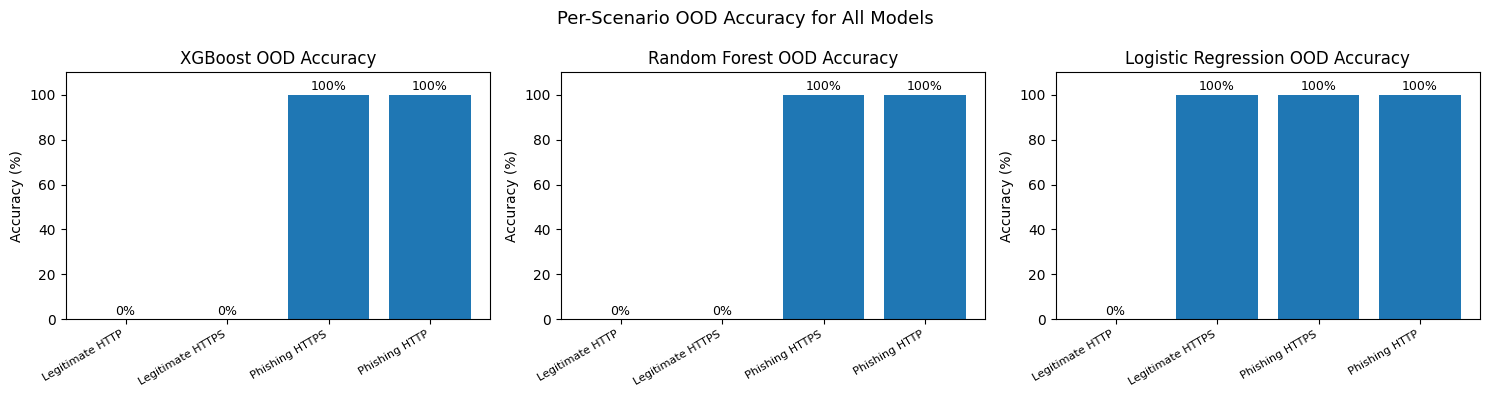

In [ ]:
"""
Real-World OOD Test

Label definition used throughout this section:
- Class 0 = Phishing
- Class 1 = Legitimate

Purpose:
- Evaluate all three models on a real-world OOD set covering four scenarios:
  legitimate HTTP, legitimate HTTPS, phishing HTTPS, and phishing HTTP.
- Feature extraction replicates the available URL-based features.
- The saved scaler is used first, then each model receives only the feature
  columns it was originally trained on.

Inputs:
- best_model: tuned Random Forest model
- best_lr_model: tuned Logistic Regression model
- best_xgb_model: tuned XGBoost model

Outputs:
- Per-URL, per-scenario, and overall OOD accuracy for each model
- Comparison bar chart across all models
"""

import re
import math
from collections import Counter
from urllib.parse import urlparse
import pandas as pd
import numpy as np
from sklearn.metrics import classification_report
import joblib
import matplotlib.pyplot as plt

# Load scaler early so feature extraction matches the training pipeline
scaler = joblib.load("/content/drive/MyDrive/phishing_scaler.pkl")

# Get scaler feature names
scaler_features = list(scaler.feature_names_in_)

# Legitimate HTTP URLs
legitimate_http_urls = [
    "http://info.cern.ch/",
    "http://www.gutenberg.org/",
    "http://neverssl.com/",
    "http://www.example.com/",
    "http://detectportal.firefox.com/"
]

# Legitimate HTTPS URLs
legitimate_https_urls = [
    "https://www.google.com/",
    "https://www.wikipedia.org/",
    "https://www.github.com/",
    "https://www.amazon.com/",
    "https://www.youtube.com/"
]

# URLhaus online feed
urlhaus_url = "https://urlhaus.abuse.ch/downloads/csv_online/"

# Load URLhaus CSV
df_urlhaus = pd.read_csv(urlhaus_url, comment="#", header=None)

# Assign column names
df_urlhaus.columns = [
    "id", "dateadded", "url", "url_status", "last_online",
    "threat", "tags", "urlhaus_link", "reporter"
]

# Keep unique URLs only
df_urlhaus = df_urlhaus.drop_duplicates(subset=["url"]).copy()

# Remove overlap with legitimate URLs
legitimate_set = set(legitimate_http_urls + legitimate_https_urls)
df_urlhaus = df_urlhaus[~df_urlhaus["url"].isin(legitimate_set)].copy()

# Select 5 phishing HTTPS URLs
phishing_https_urls = (
    df_urlhaus[df_urlhaus["url"].str.startswith("https://", na=False)]["url"]
    .drop_duplicates()
    .head(5)
    .tolist()
)

# Select 5 phishing HTTP URLs
phishing_http_urls = (
    df_urlhaus[df_urlhaus["url"].str.startswith("http://", na=False)]["url"]
    .drop_duplicates()
    .head(5)
    .tolist()
)

# Combine all URLs
all_urls = legitimate_http_urls + legitimate_https_urls + phishing_https_urls + phishing_http_urls

# Validate OOD set
assert len(phishing_https_urls) == 5, "Could not retrieve 5 phishing HTTPS URLs from URLhaus."
assert len(phishing_http_urls) == 5, "Could not retrieve 5 phishing HTTP URLs from URLhaus."
assert len(all_urls) == 20, "The OOD set must contain exactly 20 URLs."
assert len(all_urls) == len(set(all_urls)), "Duplicate URLs found in the OOD set."

# Print URL counts
print("OOD URL counts:")
print(f"  Legitimate HTTP : {len(legitimate_http_urls)}")
print(f"  Legitimate HTTPS: {len(legitimate_https_urls)}")
print(f"  Phishing HTTPS  : {len(phishing_https_urls)}")
print(f"  Phishing HTTP   : {len(phishing_http_urls)}")
print(f"  Total URLs      : {len(all_urls)}")

# Map of all extractable features from a URL
def _all_url_features(url):
    parsed = urlparse(url)
    domain = parsed.netloc
    tld = domain.split(".")[-1] if "." in domain else ""
    parts = domain.split(".")
    path = parsed.path

    return {
        "URLLength": len(url),
        "DomainLength": len(domain),
        "TLDLength": len(tld),
        "NoOfSubDomain": max(len(parts) - 2, 0),
        "NoOfObfuscatedChar": len(re.findall(r"%[0-9a-fA-F]{2}", url)),
        "NoOfURLRedirect": max(len(re.findall(r"https?://", url)) - 1, 0),
        "NoOfSelfRedirect": max(url.count(domain) - 1, 0),
        "NoOfQMarkInURL": url.count("?"),
        "IsHTTPS": 1 if parsed.scheme == "https" else 0,
        "NoOfDotsInURL": url.count("."),
        "HasSuspiciousKeywords": int(bool(re.search(
            r"(?:login|verify|secure|account|update|confirm|"
            r"bank|password|signin|alert|suspend)", url.lower()
        ))),
        "PathDepth": len([p for p in path.strip("/").split("/") if p]),
    }

# Extract only the features the scaler was trained on
def extract_features(url):
    all_feats = _all_url_features(url)
    return {k: all_feats.get(k, 0) for k in scaler_features}

# Build OOD dataset
rows, labels, url_list, scenario_list = [], [], [], []

for url in legitimate_http_urls:
    rows.append(extract_features(url))
    labels.append(1)
    url_list.append(url)
    scenario_list.append("Legitimate HTTP")

for url in legitimate_https_urls:
    rows.append(extract_features(url))
    labels.append(1)
    url_list.append(url)
    scenario_list.append("Legitimate HTTPS")

for url in phishing_https_urls:
    rows.append(extract_features(url))
    labels.append(0)
    url_list.append(url)
    scenario_list.append("Phishing HTTPS")

for url in phishing_http_urls:
    rows.append(extract_features(url))
    labels.append(0)
    url_list.append(url)
    scenario_list.append("Phishing HTTP")

# Create raw OOD DataFrame
ood_df = pd.DataFrame(rows)

# Create labels
y_ood = pd.Series(labels)

# Print extracted features
display_df = ood_df.copy()
display_df.insert(0, "Scenario", scenario_list)
display_df.insert(1, "URL", [u[:70] + "..." if len(u) > 70 else u for u in url_list])
display_df["True Label"] = y_ood.map({0: "Phishing", 1: "Legitimate"})

print("\nExtracted Features:")
print(display_df.to_string(index=False))

# Columns already aligned to scaler_features by extract_features(), no reindex needed
ood_scaled = scaler.transform(ood_df)

# Convert scaled array back to DataFrame
ood_scaled_df_full = pd.DataFrame(ood_scaled, columns=scaler_features)

# Get the exact feature names used by each model
def get_model_features(model):
    if hasattr(model, "feature_names_in_"):
        return list(model.feature_names_in_)
    if hasattr(model, "get_booster"):
        booster = model.get_booster()
        if booster.feature_names is not None:
            return list(booster.feature_names)
    raise ValueError("Could not determine feature names for this model.")

# Evaluate one model on OOD data
def run_ood(model, model_name, ood_scaled_df_full, y_ood, scenario_list, url_list):
    # Get model-specific training columns
    model_features = get_model_features(model)

    # Keep only the columns used during model training
    ood_model_df = ood_scaled_df_full[model_features]

    # Generate predictions
    y_pred = model.predict(ood_model_df)

    # Print section header
    print(f"\n{'─'*60}")
    print(f"── {model_name} Real-World OOD ──")
    print(f"{'─'*60}")

    # Print classification report
    print(classification_report(
        y_ood,
        y_pred,
        labels=[0, 1],
        target_names=["Phishing", "Legitimate"],
        zero_division=0
    ))

    # Build results table
    results = pd.DataFrame({
        "Scenario": scenario_list,
        "URL": [u[:70] + "..." if len(u) > 70 else u for u in url_list],
        "True Label": y_ood.map({0: "Phishing", 1: "Legitimate"}).values,
        "Predicted": pd.Series(y_pred).map({0: "Phishing", 1: "Legitimate"}).values,
        "Correct": (y_pred == y_ood.values)
    })

    # Print per-URL breakdown
    print("\nPer-URL Breakdown:")
    print(results.to_string(index=False))

    # Compute per-scenario accuracy
    print("\nPer-Scenario Accuracy:")
    scenario_accuracy = {}
    for scenario in ["Legitimate HTTP", "Legitimate HTTPS", "Phishing HTTPS", "Phishing HTTP"]:
        mask = [s == scenario for s in scenario_list]
        if not any(mask):
            continue
        correct = sum(results["Correct"][mask])
        total = sum(mask)
        acc = correct / total
        scenario_accuracy[scenario] = acc
        print(f"  {scenario:<20}: {correct}/{total} ({acc:.0%})")

    # Compute overall accuracy
    overall = (y_pred == y_ood.values).mean()
    print(f"\nOverall OOD Accuracy: {overall:.2%}")

    return overall, y_pred, scenario_accuracy

# Run XGBoost OOD evaluation
xgb_acc, xgb_pred, xgb_scenario_acc = run_ood(
    best_xgb_model, "XGBoost", ood_scaled_df_full, y_ood, scenario_list, url_list
)

# Run Random Forest OOD evaluation
rf_acc, rf_pred, rf_scenario_acc = run_ood(
    best_model, "Random Forest", ood_scaled_df_full, y_ood, scenario_list, url_list
)

# Run Logistic Regression OOD evaluation
lr_acc, lr_pred, lr_scenario_acc = run_ood(
    best_lr_model, "Logistic Regression", ood_scaled_df_full, y_ood, scenario_list, url_list
)

# Print summary
print("\n" + "─" * 60)
print("OOD Summary")
print("─" * 60)

summary = pd.DataFrame({
    "Model": ["Logistic Regression", "Random Forest", "XGBoost"],
    "Overall OOD Accuracy": [f"{lr_acc:.2%}", f"{rf_acc:.2%}", f"{xgb_acc:.2%}"]
})

print(summary.to_string(index=False))

# Prepare plot data
scenarios = ["Legitimate HTTP", "Legitimate HTTPS", "Phishing HTTPS", "Phishing HTTP"]
models_list = ["XGBoost", "Random Forest", "Logistic Regression"]
scenario_acc_list = [xgb_scenario_acc, rf_scenario_acc, lr_scenario_acc]

# Create subplots
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

for ax, model_name, scenario_acc in zip(axes, models_list, scenario_acc_list):
    accs = [scenario_acc.get(s, 0) * 100 for s in scenarios]
    bars = ax.bar(scenarios, accs)

    ax.set_title(f"{model_name} OOD Accuracy")
    ax.set_ylabel("Accuracy (%)")
    ax.set_ylim(0, 110)
    ax.set_xticks(range(len(scenarios)))
    ax.set_xticklabels(scenarios, rotation=30, ha="right", fontsize=8)

    for bar, acc in zip(bars, accs):
        ax.text(
            bar.get_x() + bar.get_width() / 2,
            bar.get_height() + 2,
            f"{acc:.0f}%",
            ha="center",
            fontsize=9
        )

plt.suptitle("Per-Scenario OOD Accuracy for All Models", fontsize=13)
plt.tight_layout()
plt.show()

The real world OOD test evaluated all three models on 20 manually collected URLs across four scenarios: legitimate HTTP, legitimate HTTPS, phishing HTTPS, and phishing HTTP.

Logistic Regression achieved the highest OOD accuracy at 75%, correctly classifying all phishing URLs and all legitimate HTTPS URLs. This result suggests that the model retained some ability to generalize, although its performance still reflected sensitivity to protocol based patterns.

XGBoost achieved 50% accuracy, correctly identifying all phishing URLs but misclassifying all legitimate URLs as phishing. Random Forest also achieved 50%, also failing on all legitimate URLs. This consistent failure on legitimate URLs indicates that both ensemble models learned dataset specific structural patterns rather than robust signals of legitimacy.

The shared failure across all three models on legitimate HTTP URLs confirms a key dataset limitation: the training data did not include legitimate HTTP examples, because legitimate URLs were sourced from top ranked domains that uniformly used HTTPS. As a result, the models were never exposed to legitimate HTTP URLs during training, making correct classification under this scenario highly unlikely.

Overall, these findings confirm that the strong in distribution performance of the models does not fully translate to real world generalization. Addressing this limitation would require retraining on a more diverse dataset that includes both legitimate HTTP URLs and phishing HTTPS URLs in more realistic proportions.

## 5. Model Comparison & Analysis
----

The best-performing model depends on the evaluation setting. On the standard test set, XGBoost and Random Forest achieved higher performance than Logistic Regression, which shows that the tree-based models fit the original data distribution more effectively. However, the OOD evaluation produced a different result. Logistic Regression achieved the highest overall OOD accuracy at 75%, compared with 50% for XGBoost and 50% for Random Forest for Random Forest. This indicates that Logistic Regression generalized better when the data distribution changed. Therefore, while XGBoost performed best on the standard test data, Logistic Regression performed best in terms of robustness and generalization.

Analyze misclassifications:
The misclassification analysis shows a clear pattern across the models. The most difficult category for all models was legitimate HTTP URLs. Logistic Regression correctly classified legitimate HTTPS, phishing HTTPS, and phishing HTTP samples, but failed on legitimate HTTP samples. XGBoost failed on all legitimate URLs regardless of protocol, achieving 0% on both legitimate HTTP and legitimate HTTPS scenarios, Random Forest and XGBoost both achieved 50% OOD accuracy, failing on all legitimate URLs while correctly classifying all phishing URLs. These results suggest that the models learned a strong association between protocol type and class label, especially treating HTTP as an indicator of phishing and HTTPS as an indicator of legitimacy. This pattern reflects bias in the training data rather than a reliable real-world rule.

Discuss trade-offs:
Logistic Regression is simple, fast, and easy to interpret. It also showed the strongest OOD performance, which makes it more reliable under distribution shift. Random Forest and XGBoost achieved better performance on the standard test set because they can model nonlinear relationships and feature interactions more effectively. However, these models are less interpretable, require more computational resources, and showed weaker OOD generalization. This comparison shows that higher standard test accuracy does not necessarily mean better real-world robustness.

Recommendation:
Based on the OOD evaluation, Logistic Regression is the most suitable model for the final system. Although it did not achieve the highest performance on the standard test set, it achieved the best OOD accuracy and showed greater stability under distribution shift. In addition, it is easier to interpret and less computationally expensive than the ensemble models. For these reasons, Logistic Regression is the most practical choice among the evaluated models for the current system. At the same time, the results show that the main limitation is the dataset itself. Since all models failed on legitimate HTTP URLs, improving the dataset by including more representative legitimate HTTP and phishing HTTPS samples is necessary to reduce protocol-related bias and improve real-world generalization.

### Model Comparison Table
| Model | Accuracy | Precision (0 / 1) | Recall (0 / 1) | F1-score (0 / 1) | Support (0 / 1) | OOD Accuracy |
|------|----------|------------------|----------------|------------------|-----------------|-------------|
| Logistic Regression | 0.83 | 0.76 / 0.91 | 0.90 / 0.78 | 0.82 / 0.84 | 15142 / 20228 | 0.75 |
| Random Forest | 1.00 | 1.00 / 1.00 | 0.99 / 1.00 | 1.00 / 1.00 | 15142 / 20228 | 0.50 |
| XGBoost | 1.00 | 1.00 / 1.00 | 0.99 / 1.00 | 1.00 / 1.00 | 15142 / 20228 | 0.50 |

## 6. Conclusion: Best Model Selection & Reasoning

----

Based on the standard test set results, XGBoost and Random Forest achieved better in distribution performance than Logistic Regression. However, the OOD evaluation offered a more meaningful basis for model selection because the goal of a phishing detection system is not only to perform well on familiar data, but also to remain reliable when the data distribution changes.

In the OOD test, Logistic Regression achieved the highest overall accuracy at 75%, compared with 50% for XGBoost and 40% for Random Forest. Although it did not outperform the tree based models on the standard test set, it showed better robustness and stronger generalization under shifted conditions. For this reason, it is considered the most suitable model for the final system among the three evaluated approaches.

The results also show that all models were affected by the same limitation in the dataset. In particular, all of them struggled with legitimate HTTP URLs, which suggests that the models learned strong protocol related patterns from the training data. This indicates that the differences between the models are less important than the bias present in the dataset itself.

From a practical point of view, Logistic Regression also has several advantages. It is simpler, faster, easier to interpret, and less computationally expensive than Random Forest and XGBoost. These characteristics, together with its stronger OOD performance, make it a more dependable choice for deployment in the current system.

Accordingly, Logistic Regression is selected as the final model for the phishing URL detection system. This decision is based not only on its simplicity and interpretability, but more importantly on its better generalization performance in the OOD evaluation. At the same time, the findings make it clear that improving the dataset is still necessary. Including more representative legitimate HTTP URLs and phishing HTTPS URLs would help reduce protocol related bias and improve the model’s real world robustness in future work.

##7.Next Steps for Phase 2 Integration
----

In Phase 2, the system will be enhanced by adding unsupervised learning and Generative AI. Clustering algorithms such as K-Means and DBSCAN will be used to uncover hidden patterns in URL behavior, while anomaly detection can help identify unusual or unseen cases. These methods will complement the Phase 1 supervised model by adding deeper pattern based insights beyond simple prediction. Generative AI will then be used to convert prediction results and cluster information into clear, personalized explanations, improving the usability and interpretability of the final advice system.